In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme()

In [49]:
!curl -L -o ./datasets/customer-segmentation-tutorial-in-python.zip\
  https://www.kaggle.com/api/v1/datasets/download/vjchoudhary7/customer-segmentation-tutorial-in-python
!unzip -o ./customer-segmentation-tutorial-in-python.zip -d datasets

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  1583  100  1583    0     0   4481      0 --:--:-- --:--:-- --:--:--  4481
unzip:  cannot find or open ./customer-segmentation-tutorial-in-python.zip, ./customer-segmentation-tutorial-in-python.zip.zip or ./customer-segmentation-tutorial-in-python.zip.ZIP.


In [50]:
data = pd.read_csv("datasets/Mall_Customers.csv")

In [51]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [52]:
data.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [53]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [54]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [56]:
data.rename(columns={'Annual Income (k$)': 'Annual Income','Spending Score (1-100)': 'Spending Score'}, inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      200 non-null    int64
 1   Gender          200 non-null    str  
 2   Age             200 non-null    int64
 3   Annual Income   200 non-null    int64
 4   Spending Score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [57]:
data.duplicated().sum()

np.int64(0)

In [58]:
plt.figure(figsize=(10, 6))

X = data[['Annual Income', 'Spending Score']].to_numpy()
iso_forest = IsolationForest(contamination=0.1, random_state=37)
labels = iso_forest.fit_predict(X)

<Figure size 1000x600 with 0 Axes>

In [60]:
normal_points = X[labels == 1]
anomalous_points = X[labels == -1]

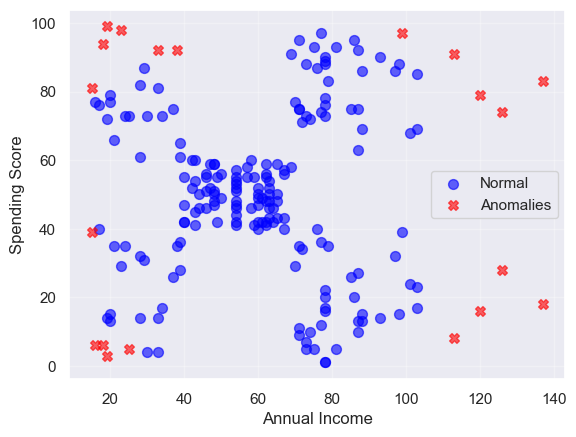

In [61]:
plt.scatter(normal_points[:, 0], normal_points[:, 1], alpha=0.6, s=50, c='blue', label='Normal')
# Plot anomalous points in red
plt.scatter(anomalous_points[:, 0], anomalous_points[:, 1], alpha=0.6, s=50, c='red', marker="X", label='Anomalies')

plt.xlabel('Annual Income')
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True,alpha=0.3)


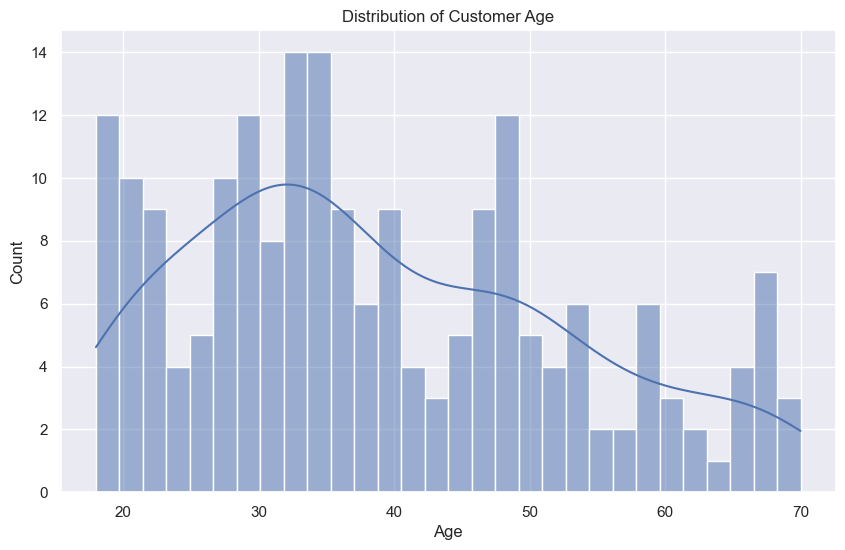

In [62]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title("Distribution of Customer Age")
plt.show()

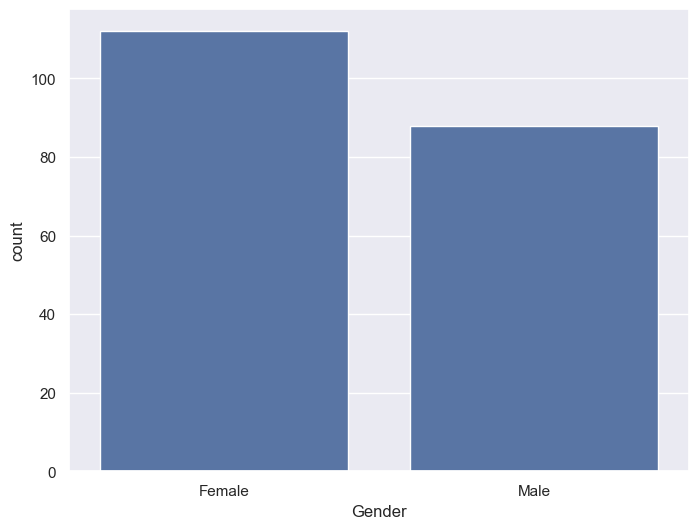

In [63]:
plt.figure(figsize=(8, 6))
gender_counts = data['Gender'].value_counts().reset_index()
sns.barplot(x='Gender', y='count', data=gender_counts)
plt.show()

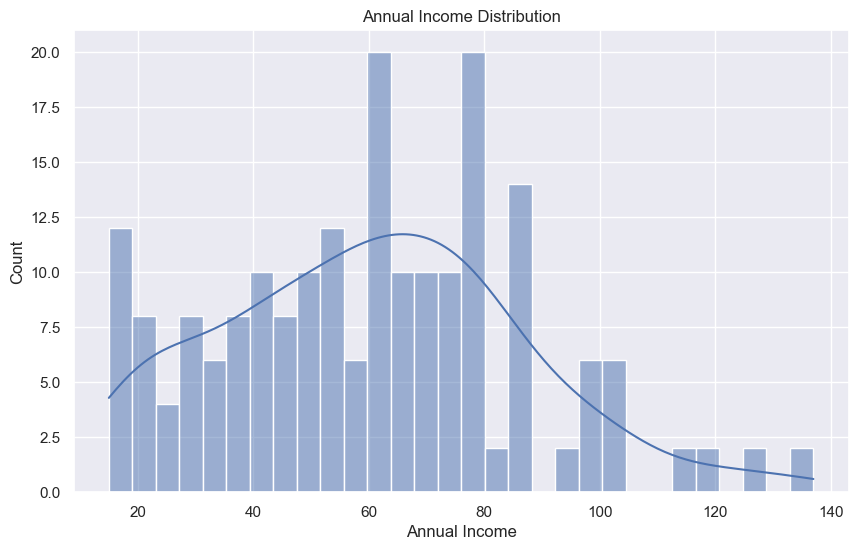

In [64]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Annual Income'], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()


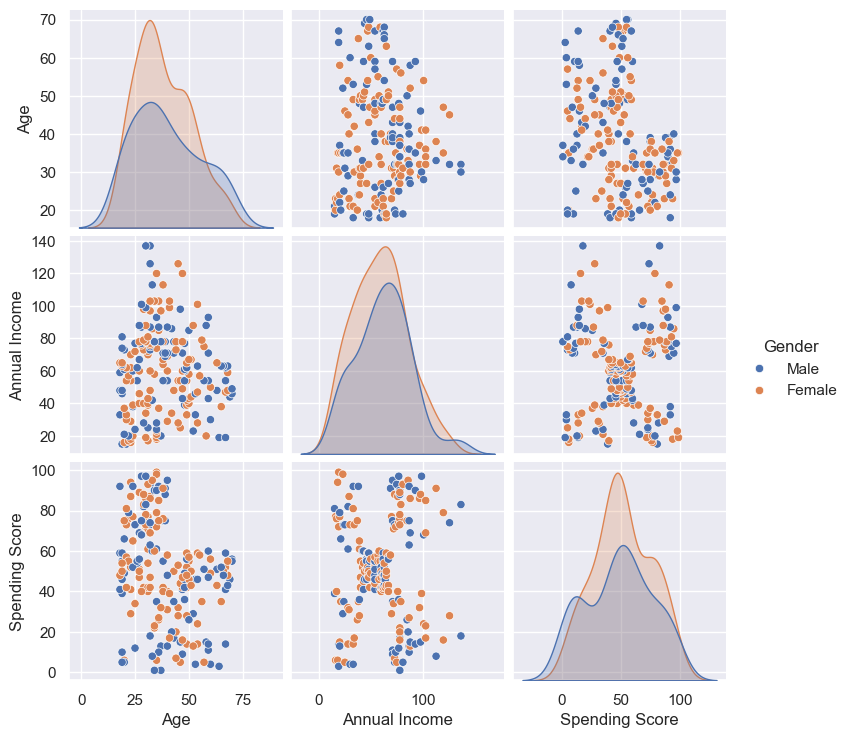

In [65]:
sns.pairplot(data.drop(columns='CustomerID'), hue='Gender')
plt.show()

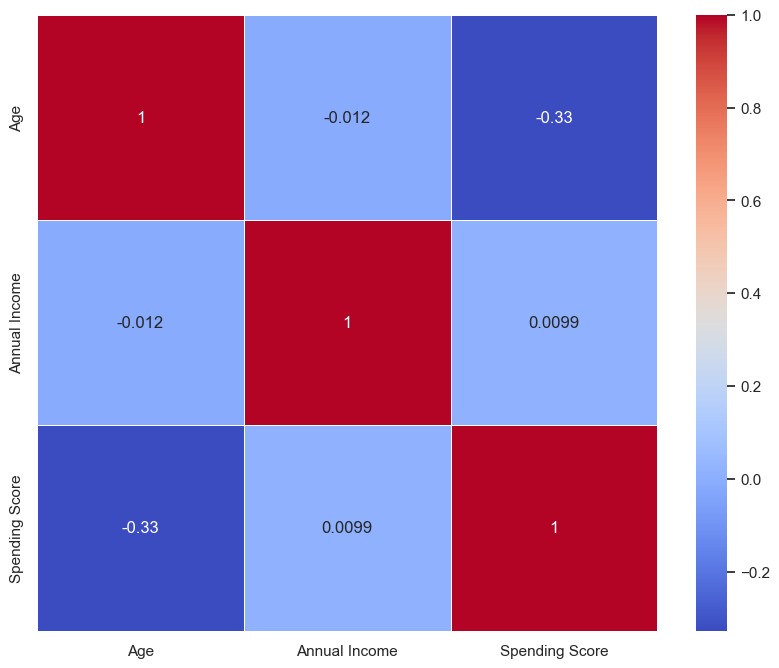

In [66]:
plt.figure(figsize=(10,8))
numeric_data = data.drop(columns='CustomerID').select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

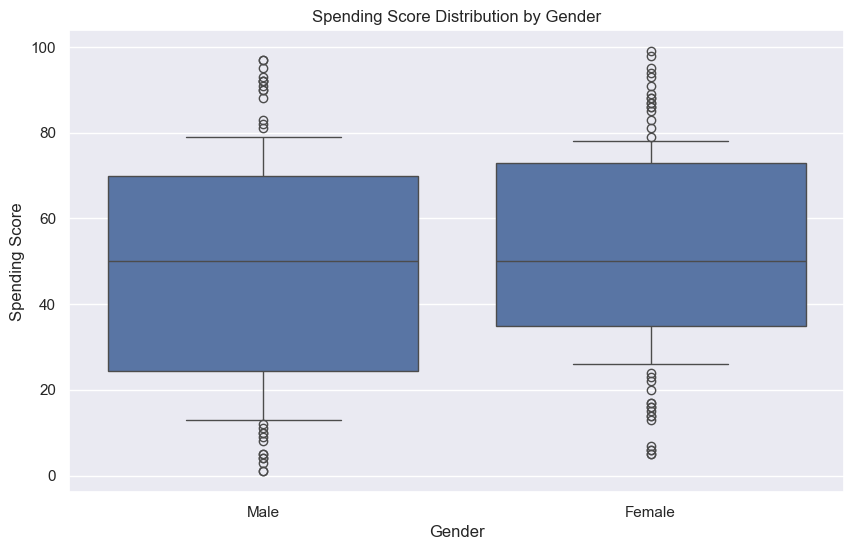

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Spending Score', data=data, legend='brief', whis=[15, 85])
# sns.violinplot(x="Gender", y="Spending Score", data=data, inner=None, color=".8")
plt.title('Spending Score Distribution by Gender')
plt.show()

Empty DataFrame
Columns: [CustomerID, Gender, Age, Annual Income, Spending Score]
Index: []
<Axes.ArtistList of 0 artists>


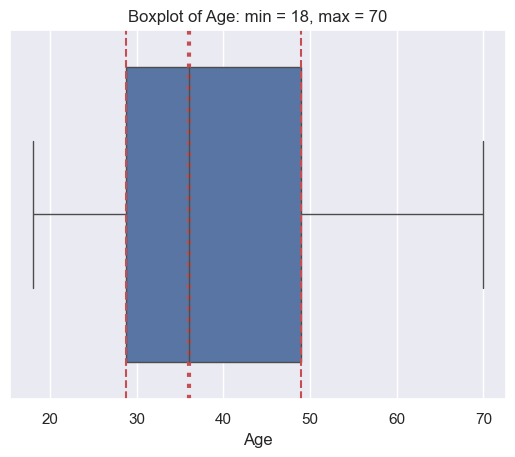

In [68]:
df = data
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
med = df['Age'].median()
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print(outliers)

min_age, max_age = data['Age'].min(), data['Age'].max()
ax = sns.boxplot(x=data['Age'])
ax.axvline(q1, color='r', ls='--')
ax.axvline(med, color='r', ls=':', lw=3)
ax.axvline(q3, color='r', ls='--')
print(ax.artists)
plt.title(f'Boxplot of Age: min = {min_age}, max = {max_age}')
plt.show()

<class 'pandas.Series'>
[137 137]
lower = -13.25, upper = 132.75


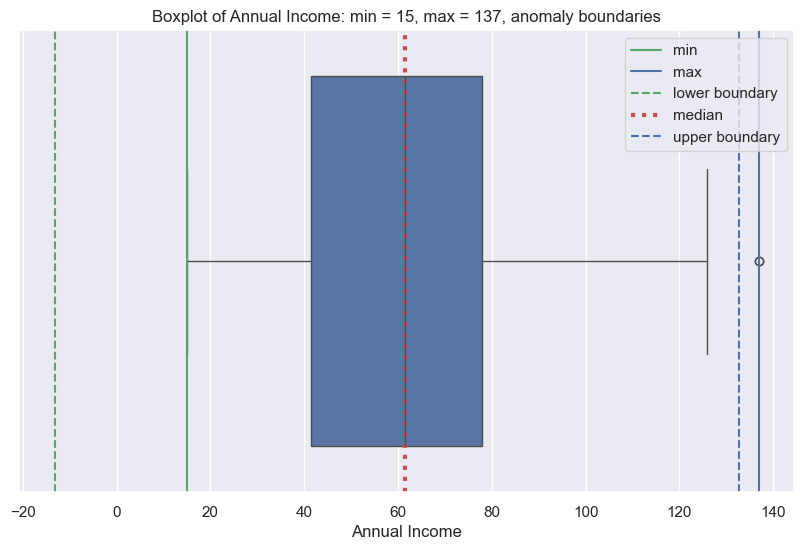

In [69]:
df = data['Annual Income']
print(type(df))
q1 = df.quantile(.25)
q3 = df.quantile(.75)
med = df.median()
iqr = q3-q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df < lower) | (df > upper)]
print(outliers.values)
print(f"lower = {lower}, upper = {upper}")

plt.figure(figsize=(10, 6))
min_age, max_age = df.min(), df.max()
ax = sns.boxplot(x=df)
ax.axvline(df.min(), color='g', label='min')
ax.axvline(df.max(), color='b', label='max')
ax.axvline(lower, color='g', ls='--', label='lower boundary')
ax.axvline(med, color='r', ls=':', lw=3, label='median')
ax.axvline(upper, color='b', ls='--', label='upper boundary')

plt.title(f'Boxplot of Annual Income: min = {min_age}, max = {max_age}, anomaly boundaries')
plt.legend()
plt.show()

<class 'pandas.Series'>
[]
lower = -22.625, upper = 130.375


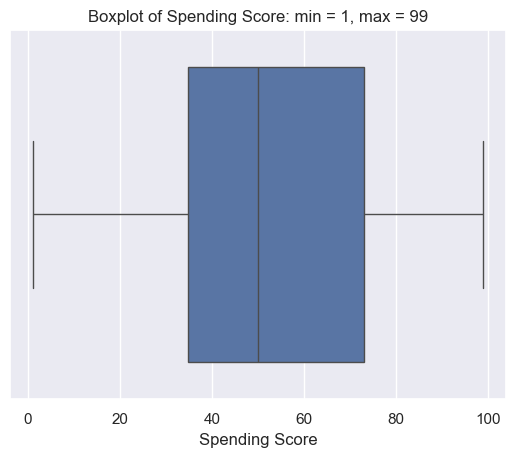

In [70]:
df = data['Spending Score']
print(type(df))
q1 = df.quantile(.25)
q3 = df.quantile(.75)
med = df.median()
iqr = q3-q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

outliers = df[(df < lower) | (df > upper)]
print(outliers.values)
print(f"lower = {lower}, upper = {upper}")

min_age, max_age = df.min(), df.max()
ax = sns.boxplot(x=df)
# ax.axvline(df.min(), color='g')
# ax.axvline(df.max(), color='g')
# ax.axvline(lower, color='r', ls='--')
# ax.axvline(med, color='r', ls=':', lw=3)
# ax.axvline(upper, color='r', ls='--')
plt.title(f'Boxplot of Spending Score: min = {min_age}, max = {max_age}')
plt.show()

# Isolation Forest for Anomaly Detection

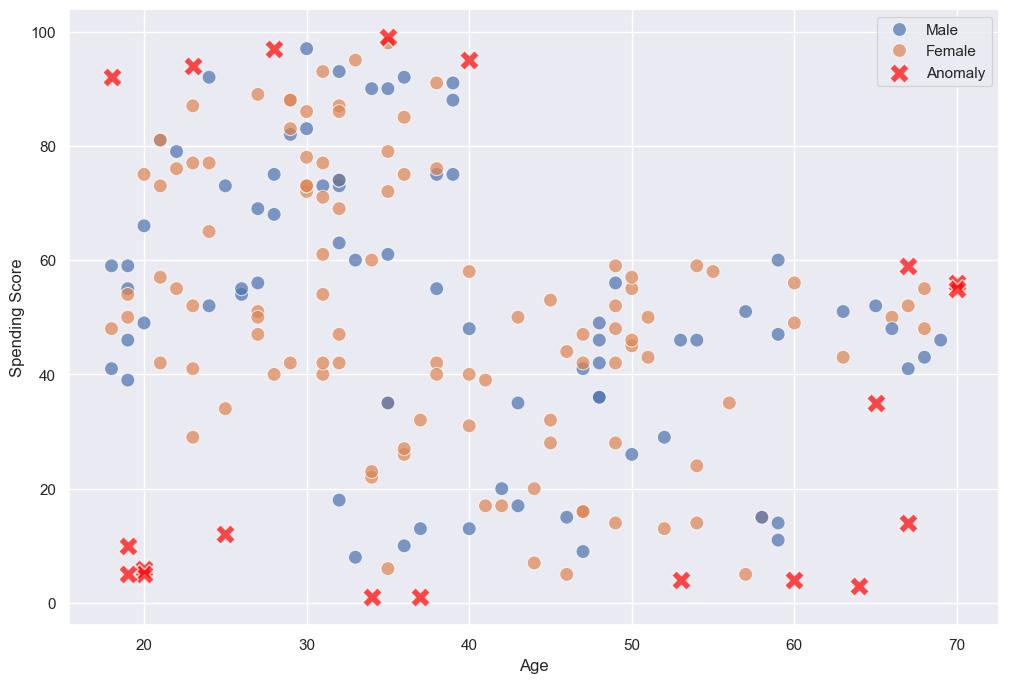

In [71]:
plt.figure(figsize=(12, 8))
X = data[['Age', 'Spending Score']].to_numpy()

iso_forest = IsolationForest(contamination=0.1, random_state=37)
labels = iso_forest.fit_predict(X)

data['Anomaly'] = labels

sns.scatterplot(x='Age', y='Spending Score', hue='Gender', data=data[data['Anomaly'] == 1],
               alpha=.7, s=100)
sns.scatterplot(x='Age', y='Spending Score', data=data[data['Anomaly'] == -1],
               alpha=.7, s=200, c='red', marker='X', label='Anomaly')
plt.show()

# Clustering with K-Means

In [112]:
features = data[['Age', 'Annual Income', 'Spending Score']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Elbow method to define K

[0.3588097740111781, 0.4039582785148566, 0.41664341513732767, 0.42841677628925934, 0.41672550059464647, 0.4277474941616527, 0.4172995820374372, 0.39905027045582153, 0.408604659677177, 0.3886936251192343, 0.37239662675867813, 0.37939777027425053, 0.35919337152875175]


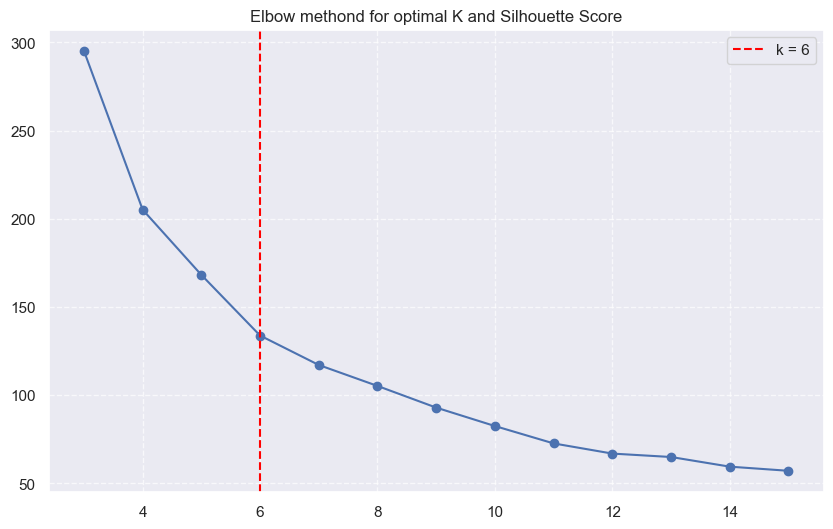

In [113]:
inertia = []
silhouette_scores = []
k_range = range(3, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=37, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(score)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')


print(silhouette_scores)

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
plt.axvline(x = best_k_silhouette, color='red', linestyle='--', 
            label=f'k = {best_k_silhouette}')

plt.title('Elbow methond for optimal K and Silhouette Score')
plt.grid(True, linestyle='--', alpha=.7)
plt.legend()
plt.show()

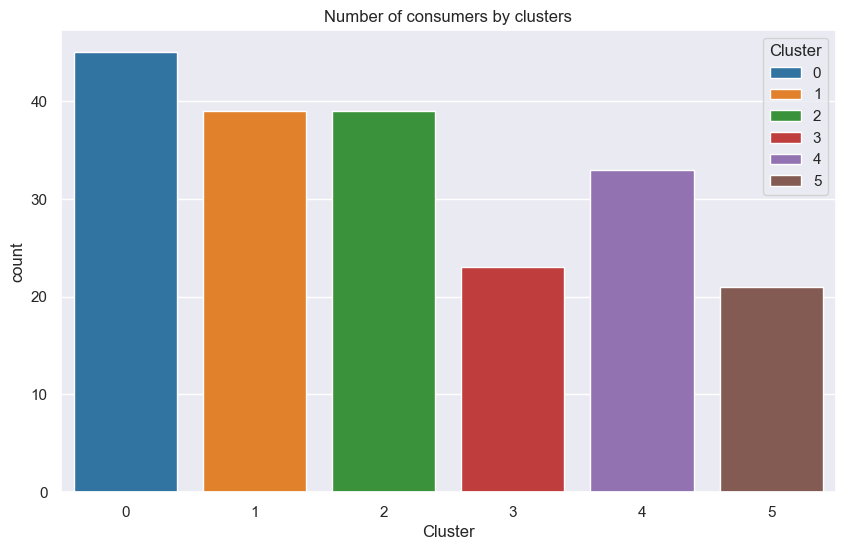

In [114]:
kmeans = KMeans(n_clusters=6, random_state=37, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)
data['Cluster'] = cluster_labels

plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Cluster', hue='Cluster', palette='tab10')
plt.title('Number of consumers by clusters')
plt.show()

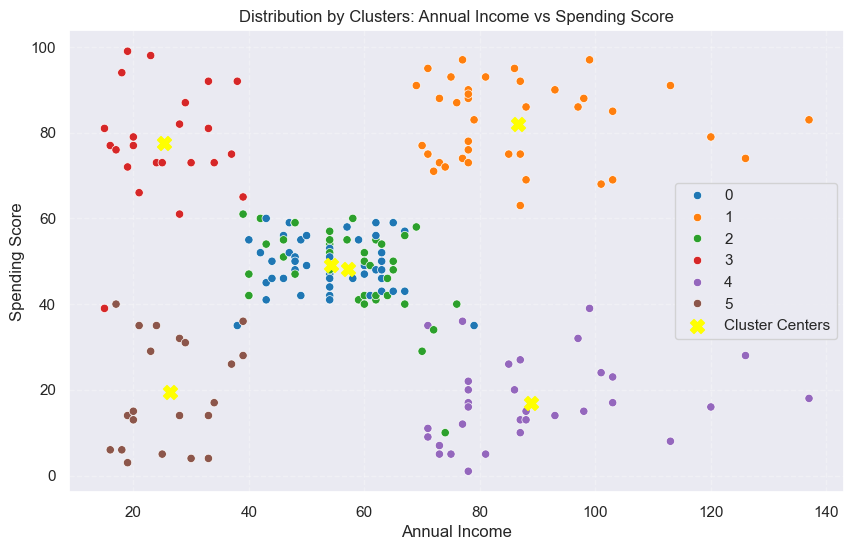

In [115]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Annual Income', y='Spending Score', hue='Cluster', palette='tab10')
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 1], centers[:, 2], c='yellow', marker='X', s=100, label='Cluster Centers')
plt.title('Distribution by Clusters: Annual Income vs Spending Score')
plt.legend()
plt.grid(True, alpha=.3, linestyle='--')
plt.show()

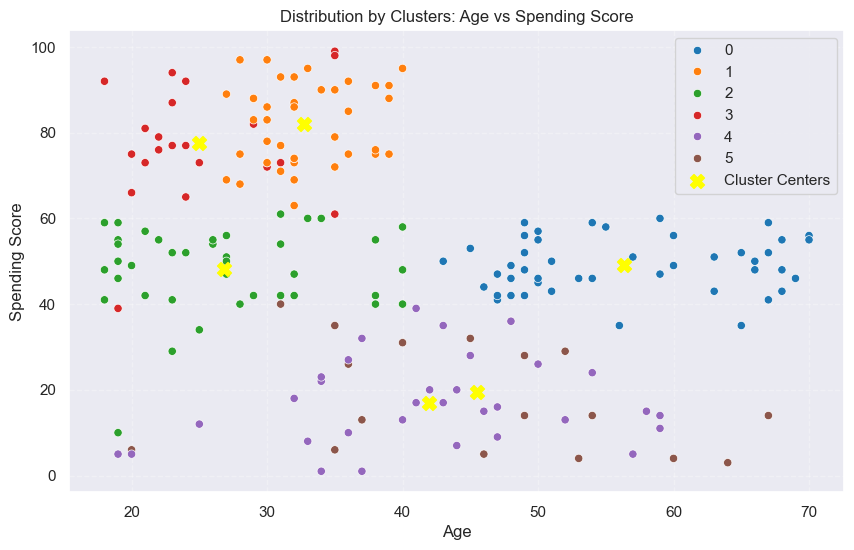

In [116]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Age', y='Spending Score', hue='Cluster', palette='tab10')
plt.scatter(centers[:, 0], centers[:, 2], c='yellow', marker='X', s=100, label='Cluster Centers')
plt.title('Distribution by Clusters: Age vs Spending Score')
plt.legend()
plt.grid(True, alpha=.3, linestyle='--')
plt.show()